# Exercise for Graph 4

In [41]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

In [42]:
class AgentState(TypedDict):
  number1: int
  operation: str
  number2: int
  finalNumber: int
  number3: int
  operation2: str
  number4: int
  finalNumber2: int

In [43]:
def adder(state: AgentState) -> AgentState:
  '''This node adds the 2 numbers'''
  state["finalNumber"] = state['number1'] + state['number2']
  return state

In [44]:
def adder2(state: AgentState) -> AgentState:
  '''This node adds the 2 numbers'''
  state["finalNumber2"] = state['number3'] + state['number4']
  return state

In [45]:
def subtractor(state: AgentState) -> AgentState:
  '''This node subtracts the 2 numbers'''
  state["finalNumber"] = state['number1'] - state['number2']
  return state

In [46]:
def subtractor2(state: AgentState) -> AgentState:
  '''This node subtracts the 2 numbers'''
  state["finalNumber2"] = state['number3'] - state['number4']
  return state

In [47]:
def decide_next_node(state: AgentState) -> AgentState:
  '''This node will select the next node of the graph'''
  if state['operation'] == "+":
    return "addition_operation"
  elif state['operation'] == "-":
    return "subtraction_operation"


In [48]:
def decide_next_node2(state: AgentState) -> AgentState:
  '''This node will select the next node of the graph'''
  if state['operation2'] == "+":
    return "addition_operation2"
  elif state['operation2'] == "-":
    return "subtraction_operation2"


In [49]:
graph = StateGraph(AgentState)

In [50]:
graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("router", lambda state: state)
graph.add_node("router2", lambda state: state)
graph.add_node("add_node2", adder2)
graph.add_node("subtract_node2", subtractor2)

In [51]:
graph.add_edge(START, "router")

In [52]:
graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }
)

In [53]:
graph.add_edge("add_node", "router2")
graph.add_edge("subtract_node", "router2")

In [54]:
graph.add_conditional_edges(
    "router2",
    decide_next_node2,
    {
        "addition_operation2": "add_node2",
        "subtraction_operation2": "subtract_node2"
    }
)

In [55]:
graph.add_edge("add_node2", END)
graph.add_edge("subtract_node2", END)

In [56]:
app = graph.compile()

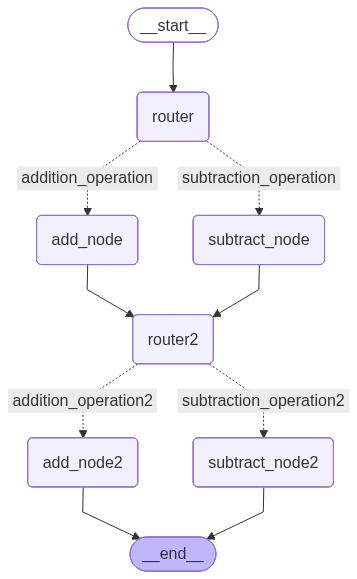

In [57]:

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [58]:
from ast import Num
initial_state_1 =  AgentState(number1=10, operation="-", number2=5, number3=7, operation2="+", number4=2)

In [59]:
print(app.invoke(initial_state_1))

{'number1': 10, 'operation': '-', 'number2': 5, 'finalNumber': 5, 'number3': 7, 'operation2': '+', 'number4': 2, 'finalNumber2': 9}
